CNN

Images extracted to: extracted_images


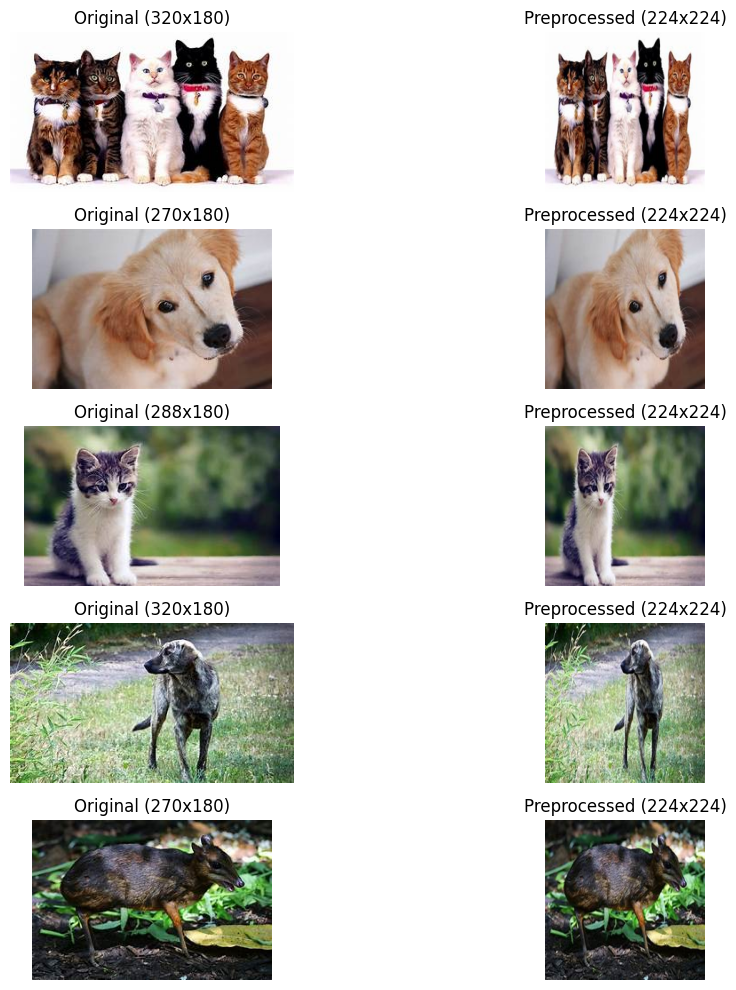

In [2]:
import zipfile
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

def extract_zip(zip_path, extract_to='extracted_images'):
    """Extracts images from a zip file."""
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Images extracted to: {extract_to}")
    return extract_to

def preprocess_image(image_path, target_size=(224, 224)):
    """Preprocess a single image."""
    image = Image.open(image_path).convert('RGB')
    resized_image = image.resize(target_size)
    image_array = img_to_array(resized_image) / 255.0
    return image, image_array  # Return original and processed separately

def display_images(original_images, preprocessed_images):
    """Display original and preprocessed images side by side."""
    plt.figure(figsize=(12, 10))
    for i in range(len(original_images)):
        # Original image
        plt.subplot(len(original_images), 2, 2 * i + 1)
        plt.imshow(original_images[i])
        plt.title(f'Original ({original_images[i].size[0]}x{original_images[i].size[1]})')  # Show dimensions
        plt.axis('off')

        # Preprocessed image
        plt.subplot(len(original_images), 2, 2 * i + 2)
        plt.imshow(preprocessed_images[i])
        plt.title('Preprocessed (224x224)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    zip_path = 'Sample.zip'  # Adjust this if you're not in Colab
    extract_to = extract_zip(zip_path)

    image_paths = []
    for root, _, files in os.walk(extract_to):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                image_paths.append(os.path.join(root, file))

    if len(image_paths) < 5:
        print("Not enough images to display. Please upload at least 5 images.")
        return

    selected_images = random.sample(image_paths, 5)
    original_images = []
    preprocessed_images = []

    for img_path in selected_images:
        original, preprocessed = preprocess_image(img_path)
        original_images.append(original)
        preprocessed_images.append(preprocessed)

    display_images(original_images, preprocessed_images)

if __name__ == "__main__":
    main()

VIT

Images extracted to: extracted_images


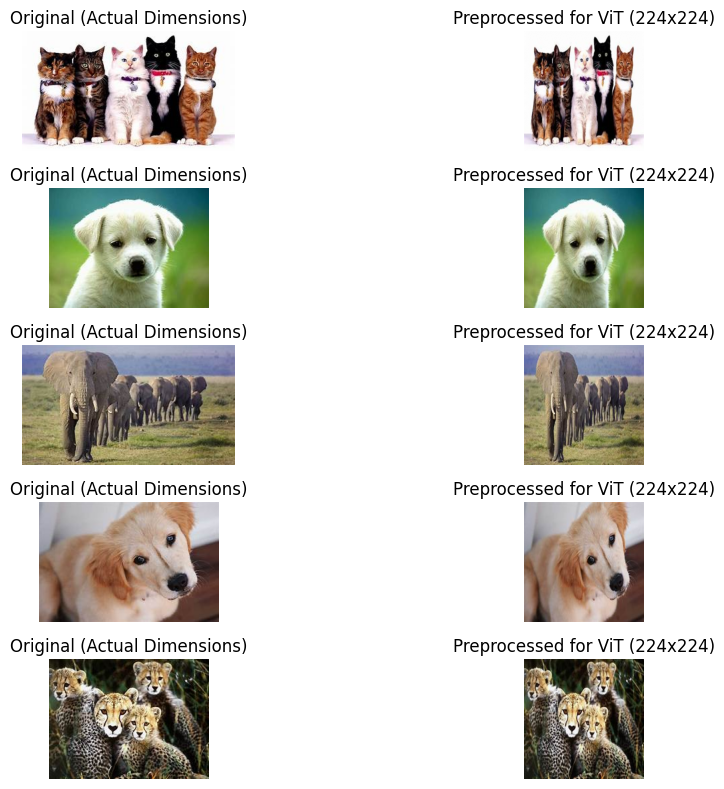

In [3]:
import zipfile
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def extract_zip(zip_path, extract_to='extracted_images'):
    """ Extracts images from a zip file. """
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Images extracted to: {extract_to}")
    return extract_to

def preprocess_image(image_path, target_size=(224, 224)):
    """ Preprocess a single image for ViT. """
    image = Image.open(image_path).convert('RGB')
    original_image = image.copy()  # Keep the original image without resizing
    image = image.resize(target_size)
    image_array = np.array(image) / 255.0
    # Normalize using ViT-specific mean and std
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    normalized_image = (image_array - mean) / std
    return original_image, normalized_image

def display_images(original_images, preprocessed_images):
    """ Display original and preprocessed images side by side. """
    plt.figure(figsize=(12, 8))
    for i in range(5):
        plt.subplot(5, 2, 2 * i + 1)
        plt.imshow(original_images[i])
        plt.title('Original (Actual Dimensions)')
        plt.axis('off')

        plt.subplot(5, 2, 2 * i + 2)
        plt.imshow(np.clip((preprocessed_images[i] * 0.5 + 0.5), 0, 1)) # Denormalized for visualization
        plt.title('Preprocessed for ViT (224x224)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    zip_path = '/content/Sample.zip'
    extract_to = extract_zip(zip_path)

    image_paths = []
    for root, _, files in os.walk(extract_to):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                image_paths.append(os.path.join(root, file))

    if len(image_paths) < 5:
        print("Not enough images to display. Please upload more than 5 images.")
        return

    selected_images = random.sample(image_paths, 5)
    original_images = []
    preprocessed_images = []

    for img_path in selected_images:
        original, preprocessed = preprocess_image(img_path)
        original_images.append(original)
        preprocessed_images.append(preprocessed)

    display_images(original_images, preprocessed_images)

if __name__ == "__main__":
    main()


SWIN

Images extracted to: extracted_images


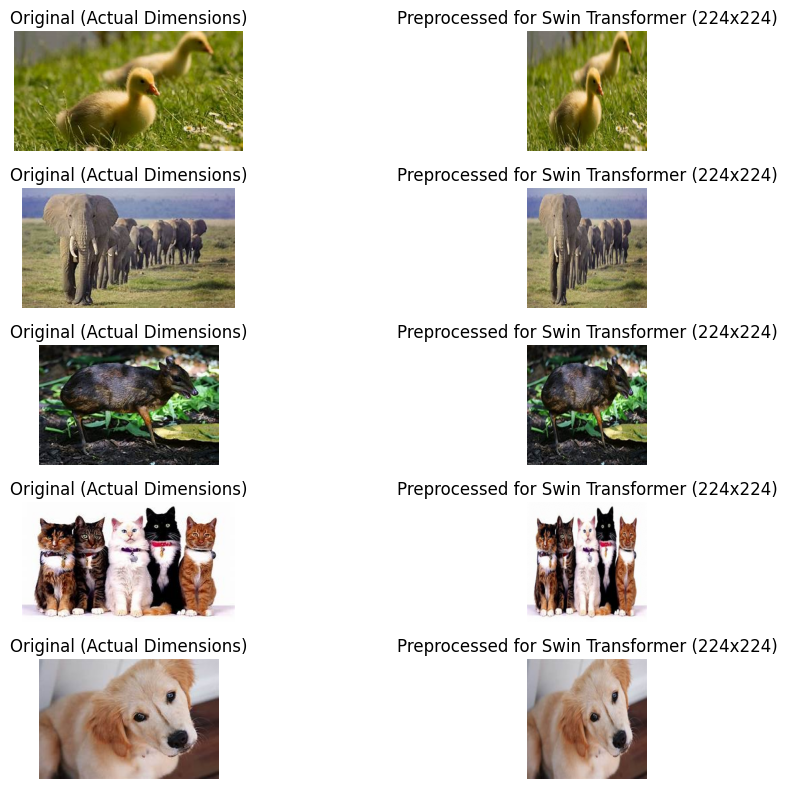

In [4]:
import zipfile
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def extract_zip(zip_path, extract_to='extracted_images'):
    """ Extracts images from a zip file. """
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Images extracted to: {extract_to}")
    return extract_to

def preprocess_image(image_path, target_size=(224, 224)):
    """ Preprocess a single image for Swin Transformer. """
    image = Image.open(image_path).convert('RGB')
    original_image = image.copy()  # Keep the original image without resizing
    image = image.resize(target_size)
    image_array = np.array(image) / 255.0
    # Normalize using Swin Transformer-specific mean and std
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    normalized_image = (image_array - mean) / std
    return original_image, normalized_image, mean, std # Return mean and std

def display_images(original_images, preprocessed_images, mean, std): # Add mean and std as arguments
    """ Display original and preprocessed images side by side. """
    plt.figure(figsize=(12, 8))
    for i in range(5):
        plt.subplot(5, 2, 2 * i + 1)
        plt.imshow(original_images[i])
        plt.title('Original (Actual Dimensions)')
        plt.axis('off')

        plt.subplot(5, 2, 2 * i + 2)
        plt.imshow(np.clip((preprocessed_images[i] * std + mean), 0, 1)) # Denormalized for visualization
        plt.title('Preprocessed for Swin Transformer (224x224)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    zip_path = '/content/Sample.zip'
    extract_to = extract_zip(zip_path)

    image_paths = []
    for root, _, files in os.walk(extract_to):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                image_paths.append(os.path.join(root, file))

    if len(image_paths) < 5:
        print("Not enough images to display. Please upload more than 5 images.")
        return

    selected_images = random.sample(image_paths, 5)
    original_images = []
    preprocessed_images = []
    means = [] # List to store mean values
    stds = [] # List to store std values

    for img_path in selected_images:
        original, preprocessed, mean, std = preprocess_image(img_path) # Get mean and std
        original_images.append(original)
        preprocessed_images.append(preprocessed)
        means.append(mean)
        stds.append(std)

    # Pass mean and std to display_images
    display_images(original_images, preprocessed_images, means[0], stds[0]) # Using the first mean and std

if __name__ == "__main__":
    main()